
# Sesión 02 — Modelos de Clasificación
**Ingeniería del Conocimiento (ISO56B)** · UNCP · 2026-II

**Docente:** Msc. Jaime Antonio Huaytalla Pariona

**Dataset:** Breast Cancer Wisconsin (569 muestras, 30 features, clasificación binaria)

---

## 1. Configuración del entorno

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_score, recall_score, f1_score, roc_curve, auc,
    ConfusionMatrixDisplay, RocCurveDisplay
)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print('✓ Librerías cargadas correctamente')

✓ Librerías cargadas correctamente


---
## 2. Carga y exploración del dataset

El dataset **Breast Cancer Wisconsin** contiene 569 muestras de biopsias de mama con 30 features numéricas computadas a partir de imágenes digitalizadas de aspiración con aguja fina (FNA). El target es binario: **maligno (0)** o **benigno (1)**.

In [3]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df['diagnosis'] = df['target'].map({0: 'maligno', 1: 'benigno'})

print(f'Dataset: {df.shape[0]} muestras, {df.shape[1]-2} features')
print(f'\nDistribución de clases:')
print(df['diagnosis'].value_counts())
print(f'\nProporción: {df["target"].mean():.1%} benigno, {1-df["target"].mean():.1%} maligno')

Dataset: 569 muestras, 30 features

Distribución de clases:
diagnosis
benigno    357
maligno    212
Name: count, dtype: int64

Proporción: 62.7% benigno, 37.3% maligno


In [4]:
df.describe().round(3)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,...,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000
mean,14.127,19.290,91.969,654.889,0.096,0.104,0.089,0.049,0.181,0.063,...,25.677,107.261,880.583,0.132,0.254,0.272,0.115,0.290,0.084,0.627
std,3.524,4.301,24.299,351.914,0.014,0.053,0.080,0.039,0.027,0.007,...,6.146,33.603,569.357,0.023,0.157,0.209,0.066,0.062,0.018,0.484
min,6.981,9.710,43.790,143.500,0.053,0.019,0.000,0.000,0.106,0.050,...,12.020,50.410,185.200,0.071,0.027,0.000,0.000,0.156,0.055,0.000
25%,11.700,16.170,75.170,420.300,0.086,0.065,0.030,0.020,0.162,0.058,...,21.080,84.110,515.300,0.117,0.147,0.114,0.065,0.250,0.071,0.000
50%,13.370,18.840,86.240,551.100,0.096,0.093,0.062,0.034,0.179,0.062,...,25.410,97.660,686.500,0.131,0.212,0.227,0.100,0.282,0.080,1.000
75%,15.780,21.800,104.100,782.700,0.105,0.130,0.131,0.074,0.196,0.066,...,29.720,125.400,1084.000,0.146,0.339,0.383,0.161,0.318,0.092,1.000
max,28.110,39.280,188.500,2501.000,0.163,0.345,0.427,0.201,0.304,0.097,...,49.540,251.200,4254.000,0.223,1.058,1.252,0.291,0.664,0.208,1.000


---
## 3. Análisis exploratorio orientado a clasificación

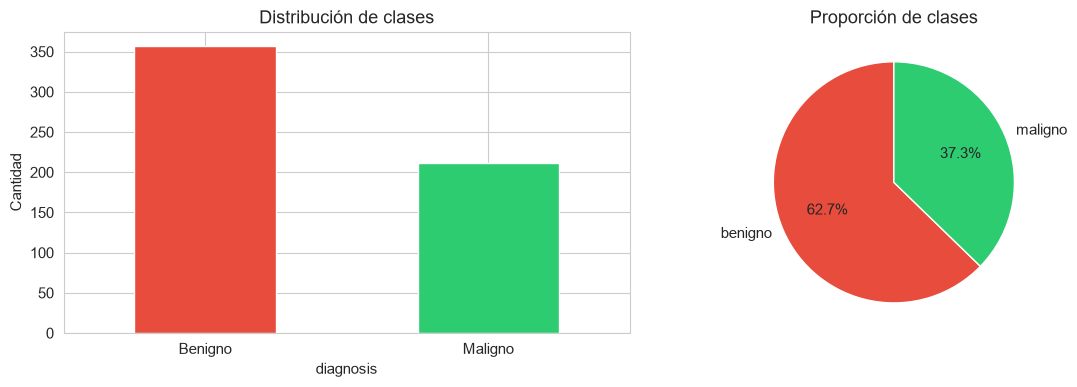

In [5]:
# 3.1  Distribución de clases
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Conteo
colors = ['#e74c3c', '#2ecc71']
df['diagnosis'].value_counts().plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('Distribución de clases')
axes[0].set_ylabel('Cantidad')
axes[0].set_xticklabels(['Benigno', 'Maligno'], rotation=0)

# Pie chart
df['diagnosis'].value_counts().plot(kind='pie', ax=axes[1], colors=colors,
    autopct='%1.1f%%', startangle=90)
axes[1].set_ylabel('')
axes[1].set_title('Proporción de clases')

plt.tight_layout()
plt.show()

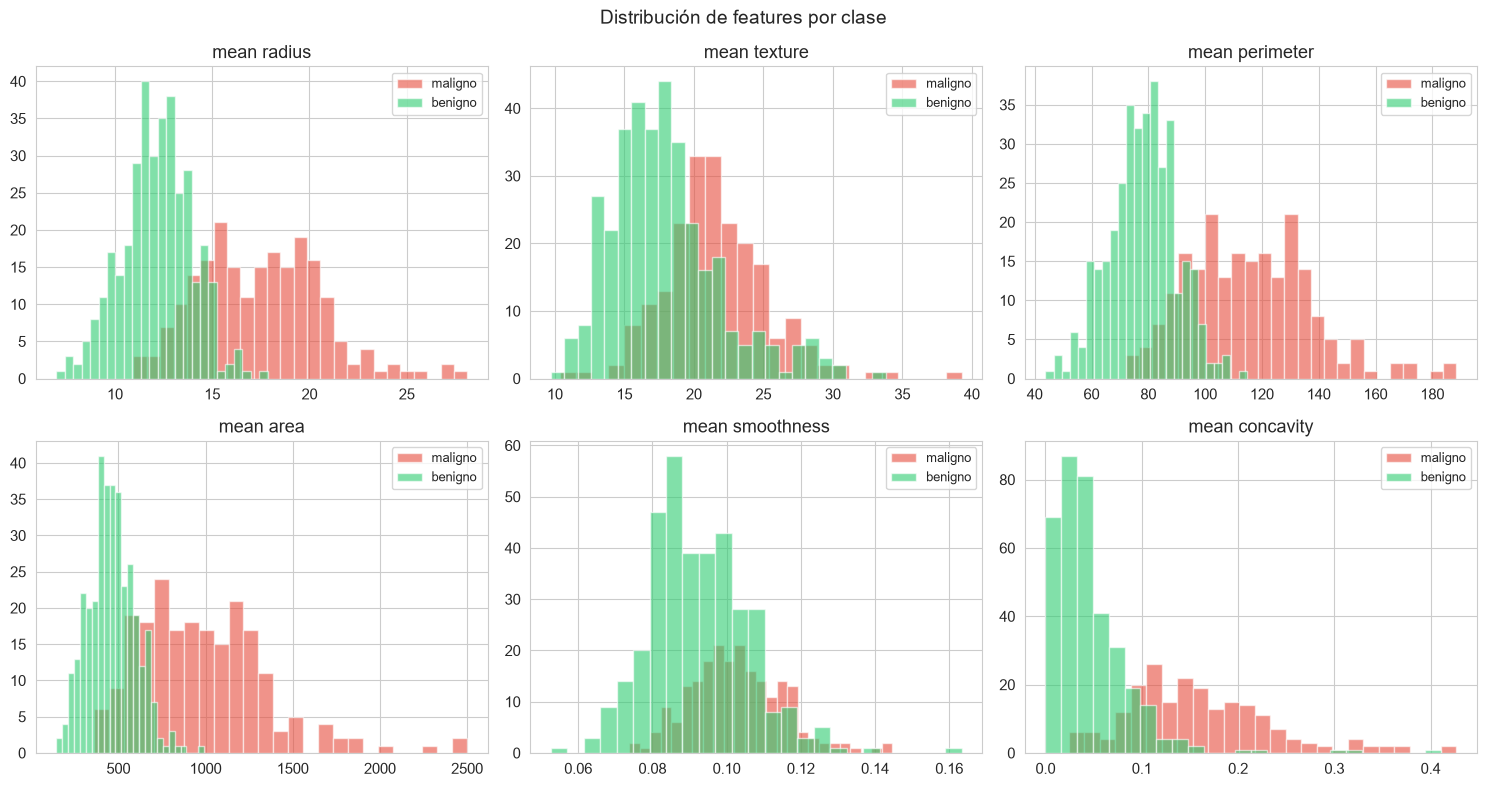

In [6]:
# 3.2  Distribución de features clave por clase
key_features = ['mean radius', 'mean texture', 'mean perimeter',
                'mean area', 'mean smoothness', 'mean concavity']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, feat in enumerate(key_features):
    ax = axes[i//3, i%3]
    for label, color in zip([0, 1], colors):
        subset = df[df['target'] == label][feat]
        ax.hist(subset, bins=25, alpha=0.6, color=color,
                label='maligno' if label == 0 else 'benigno')
    ax.set_title(feat)
    ax.legend(fontsize=9)

plt.suptitle('Distribución de features por clase', fontsize=14)
plt.tight_layout()
plt.show()

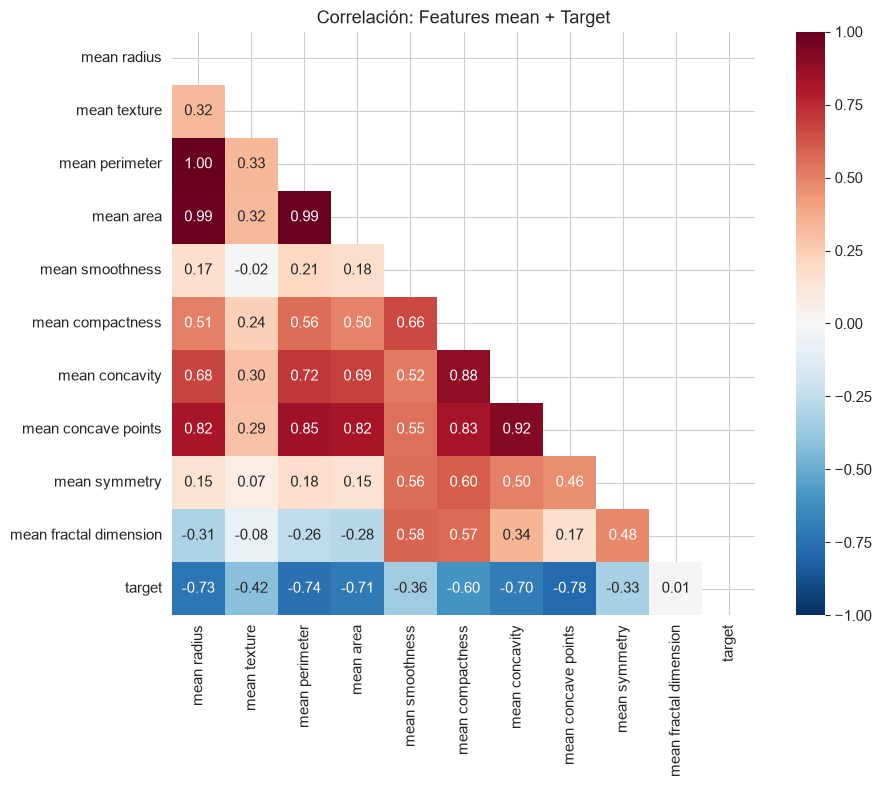

In [7]:
# 3.3  Matriz de correlación (features mean)
mean_features = [c for c in df.columns if 'mean' in c]
plt.figure(figsize=(10, 8))
corr = df[mean_features + ['target']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True)
plt.title('Correlación: Features mean + Target')
plt.tight_layout()
plt.show()

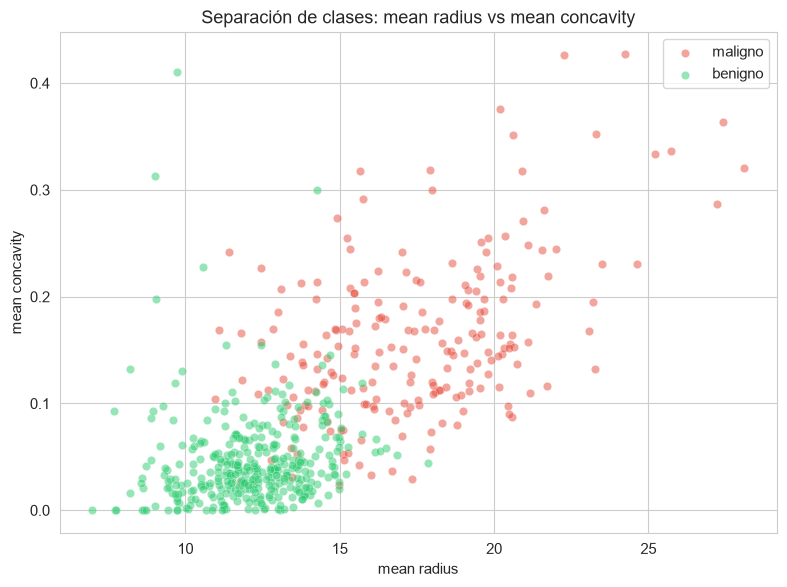

In [8]:
# 3.4  Scatter plot: 2 features más discriminativas
fig, ax = plt.subplots(figsize=(8, 6))
for label, color, name in zip([0, 1], colors, ['maligno', 'benigno']):
    mask = df['target'] == label
    ax.scatter(df.loc[mask, 'mean radius'], df.loc[mask, 'mean concavity'],
              alpha=0.5, c=color, label=name, edgecolors='w', linewidth=0.3)
ax.set_xlabel('mean radius')
ax.set_ylabel('mean concavity')
ax.set_title('Separación de clases: mean radius vs mean concavity')
ax.legend()
plt.tight_layout()
plt.show()

---
## 4. Preparación de datos

In [9]:
X = df[data.feature_names].copy()
y = df['target'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Entrenamiento: {X_train.shape[0]} muestras')
print(f'Test:          {X_test.shape[0]} muestras')
print(f'\nProporción en train: {y_train.mean():.1%} benigno')
print(f'Proporción en test:  {y_test.mean():.1%} benigno')

# Stratified K-Fold para validación cruzada
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Entrenamiento: 455 muestras
Test:          114 muestras

Proporción en train: 62.6% benigno
Proporción en test:  63.2% benigno


### Funciones auxiliares para evaluación de clasificadores

In [10]:
def eval_classifier(model, X_tr, y_tr, X_te, y_te, model_name='Modelo'):
    """Evalúa un clasificador: métricas, matriz de confusión y reporte."""
    y_pred = model.predict(X_te)
    
    metrics = {
        'Accuracy':  accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred, zero_division=0),
        'Recall':    recall_score(y_te, y_pred),
        'F1-Score':  f1_score(y_te, y_pred)
    }
    
    print(f'=== {model_name} ===')
    for k, v in metrics.items():
        print(f'  {k}: {v:.4f}')
    
    # Matriz de confusión
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    cm = confusion_matrix(y_te, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Maligno', 'Benigno'],
                yticklabels=['Maligno', 'Benigno'])
    axes[0].set_title(f'Matriz de Confusión — {model_name}')
    axes[0].set_xlabel('Predicción')
    axes[0].set_ylabel('Real')
    
    # Desglose FP y FN
    tn, fp, fn, tp = cm.ravel()
    labels = ['TN\n(benigno\ncorrecto)', 'FP\n(benigno→\nmaligno)',
              'FN\n(maligno→\nbenigno)', 'TP\n(maligno\ncorrecto)']
    values = [tn, fp, fn, tp]
    bar_colors = ['#2ecc71', '#f39c12', '#e74c3c', '#3498db']
    axes[1].bar(labels, values, color=bar_colors)
    axes[1].set_title(f'Desglose — {model_name}')
    axes[1].set_ylabel('Cantidad')
    
    plt.tight_layout()
    plt.show()
    
    print(f'\n  FN (maligno no detectado): {fn}')
    print(f'  FP (benigno como maligno): {fp}')
    print(f'\nReporte completo:')
    print(classification_report(y_te, y_pred,
          target_names=['maligno', 'benigno']))
    
    return metrics


def plot_roc(model, X_te, y_te, model_name='Modelo', ax=None):
    """Genera la curva ROC de un modelo."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))
    
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_te)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_score = model.decision_function(X_te)
    else:
        print(f'{model_name}: no soporta probabilidades')
        return None
    
    fpr, tpr, _ = roc_curve(y_te, y_score)
    roc_auc = auc(fpr, tpr)
    
    ax.plot(fpr, tpr, linewidth=2,
            label=f'{model_name} (AUC = {roc_auc:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
    ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
    ax.set_title(f'Curva ROC — {model_name}')
    ax.legend()
    
    return roc_auc

---
## 5. Modelo 1 — Regresión Logística

**Fundamento:** Modelo lineal que estima P(y=1|x) mediante la función sigmoide σ(z) = 1/(1+e^(−z)). La frontera de decisión es lineal en el espacio de features. Se optimiza minimizando la Log-Loss (entropía cruzada binaria) con regularización L2 por defecto.

In [11]:
# 5.1  Pipeline con estandarización
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

# Validación cruzada estratificada
cv_lr = cross_validate(pipe_lr, X_train, y_train, cv=skf,
                       scoring=['accuracy', 'f1', 'recall'],
                       return_train_score=True)

print('Regresión Logística — Cross-Validation (5-fold)')
print(f'  Accuracy:  {cv_lr["test_accuracy"].mean():.4f} ± {cv_lr["test_accuracy"].std():.4f}')
print(f'  F1-Score:  {cv_lr["test_f1"].mean():.4f} ± {cv_lr["test_f1"].std():.4f}')
print(f'  Recall:    {cv_lr["test_recall"].mean():.4f} ± {cv_lr["test_recall"].std():.4f}')

# Entrenar modelo final
pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)

Regresión Logística — Cross-Validation (5-fold)
  Accuracy:  0.9780 ± 0.0098
  F1-Score:  0.9825 ± 0.0078
  Recall:    0.9860 ± 0.0131


=== Regresión Logística ===
  Accuracy: 0.9825
  Precision: 0.9861
  Recall: 0.9861
  F1-Score: 0.9861


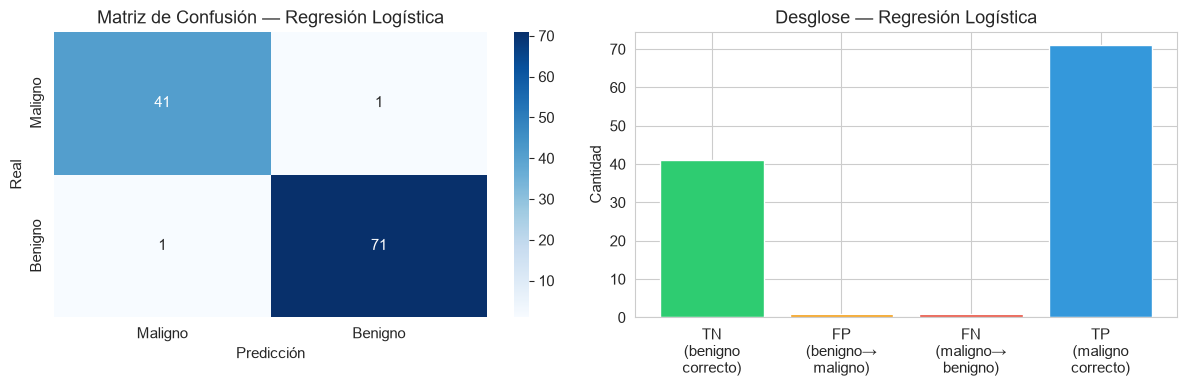


  FN (maligno no detectado): 1
  FP (benigno como maligno): 1

Reporte completo:
              precision    recall  f1-score   support

     maligno       0.98      0.98      0.98        42
     benigno       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [12]:
# 5.2  Evaluación completa
metrics_lr = eval_classifier(pipe_lr, X_train, y_train, X_test, y_test,
                             'Regresión Logística')

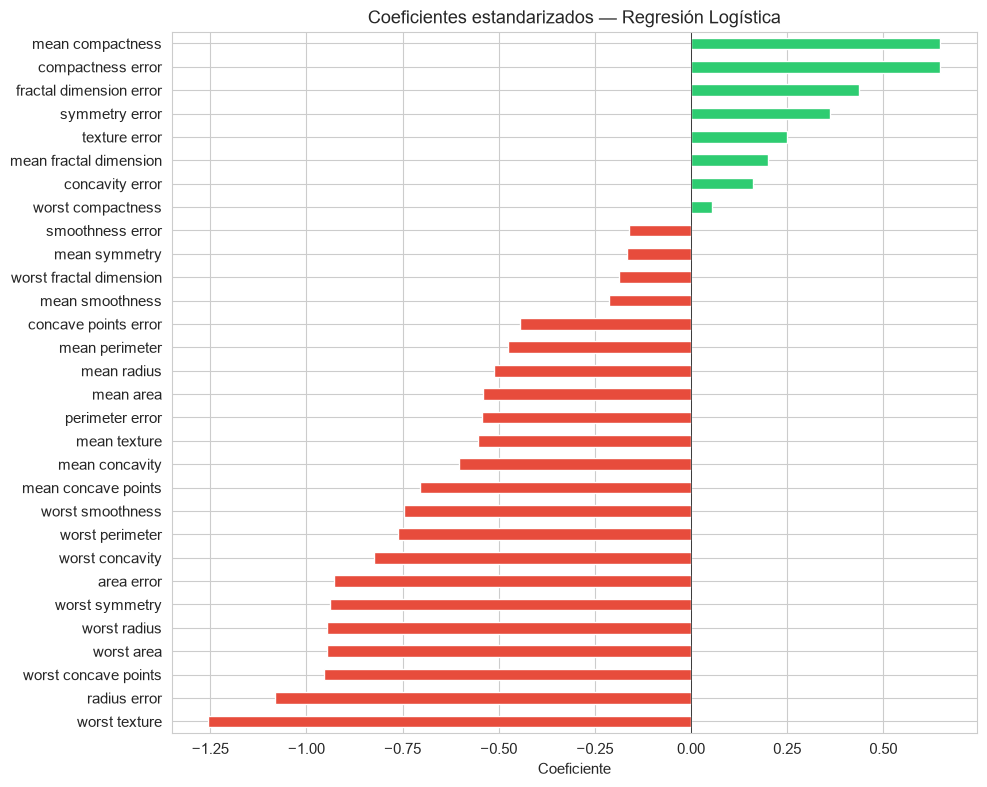

Interpretación:
  → Features que más indican MALIGNO: ['worst texture', 'radius error', 'worst concave points']
  → Features que más indican BENIGNO: ['fractal dimension error', 'compactness error', 'mean compactness']


In [13]:
# 5.3  Coeficientes estandarizados
coefs = pd.Series(
    pipe_lr.named_steps['clf'].coef_[0],
    index=data.feature_names
).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors_bar = ['#e74c3c' if c < 0 else '#2ecc71' for c in coefs]
coefs.plot(kind='barh', ax=ax, color=colors_bar)
ax.set_title('Coeficientes estandarizados — Regresión Logística')
ax.set_xlabel('Coeficiente')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print('Interpretación:')
print(f'  → Features que más indican MALIGNO: {coefs.head(3).index.tolist()}')
print(f'  → Features que más indican BENIGNO: {coefs.tail(3).index.tolist()}')

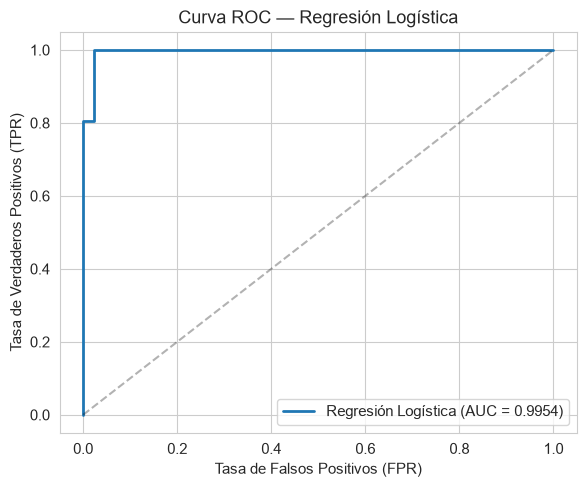

AUC: 0.9954


In [14]:
# 5.4  Curva ROC
fig, ax = plt.subplots(figsize=(6, 5))
auc_lr = plot_roc(pipe_lr, X_test, y_test, 'Regresión Logística', ax)
plt.tight_layout()
plt.show()
print(f'AUC: {auc_lr:.4f}')

---
## 6. Modelo 2 — Árbol de Decisión

**Fundamento:** CART construye particiones recursivas del espacio de features. En cada nodo selecciona la feature y el umbral que maximizan la reducción de impureza (Gini: G(t) = 1 − Σpₖ²). Las particiones son ortogonales a los ejes.

In [15]:
# 6.1  Árbol sin restricciones (para mostrar sobreajuste)
pipe_dt_full = Pipeline([
    ('clf', DecisionTreeClassifier(random_state=42))
])

cv_dt_full = cross_validate(pipe_dt_full, X_train, y_train, cv=skf,
                            scoring=['accuracy', 'f1', 'recall'],
                            return_train_score=True)

print('Árbol de Decisión (SIN restricciones) — CV 5-fold')
print(f'  Train Accuracy: {cv_dt_full["train_accuracy"].mean():.4f}')
print(f'  Test Accuracy:  {cv_dt_full["test_accuracy"].mean():.4f} ± {cv_dt_full["test_accuracy"].std():.4f}')
print(f'  Test F1-Score:  {cv_dt_full["test_f1"].mean():.4f} ± {cv_dt_full["test_f1"].std():.4f}')
print(f'\n⚠ Train accuracy ~1.0 indica sobreajuste')

Árbol de Decisión (SIN restricciones) — CV 5-fold
  Train Accuracy: 1.0000
  Test Accuracy:  0.9165 ± 0.0179
  Test F1-Score:  0.9319 ± 0.0144

⚠ Train accuracy ~1.0 indica sobreajuste


In [16]:
# 6.2  Árbol con pre-poda
pipe_dt = Pipeline([
    ('clf', DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    ))
])

cv_dt = cross_validate(pipe_dt, X_train, y_train, cv=skf,
                       scoring=['accuracy', 'f1', 'recall'],
                       return_train_score=True)

print('Árbol de Decisión (con pre-poda) — CV 5-fold')
print(f'  Train Accuracy: {cv_dt["train_accuracy"].mean():.4f}')
print(f'  Test Accuracy:  {cv_dt["test_accuracy"].mean():.4f} ± {cv_dt["test_accuracy"].std():.4f}')
print(f'  Test F1-Score:  {cv_dt["test_f1"].mean():.4f} ± {cv_dt["test_f1"].std():.4f}')
print(f'  Test Recall:    {cv_dt["test_recall"].mean():.4f} ± {cv_dt["test_recall"].std():.4f}')

pipe_dt.fit(X_train, y_train)
y_pred_dt = pipe_dt.predict(X_test)

Árbol de Decisión (con pre-poda) — CV 5-fold
  Train Accuracy: 0.9747
  Test Accuracy:  0.9275 ± 0.0226
  Test F1-Score:  0.9417 ± 0.0189
  Test Recall:    0.9368 ± 0.0325


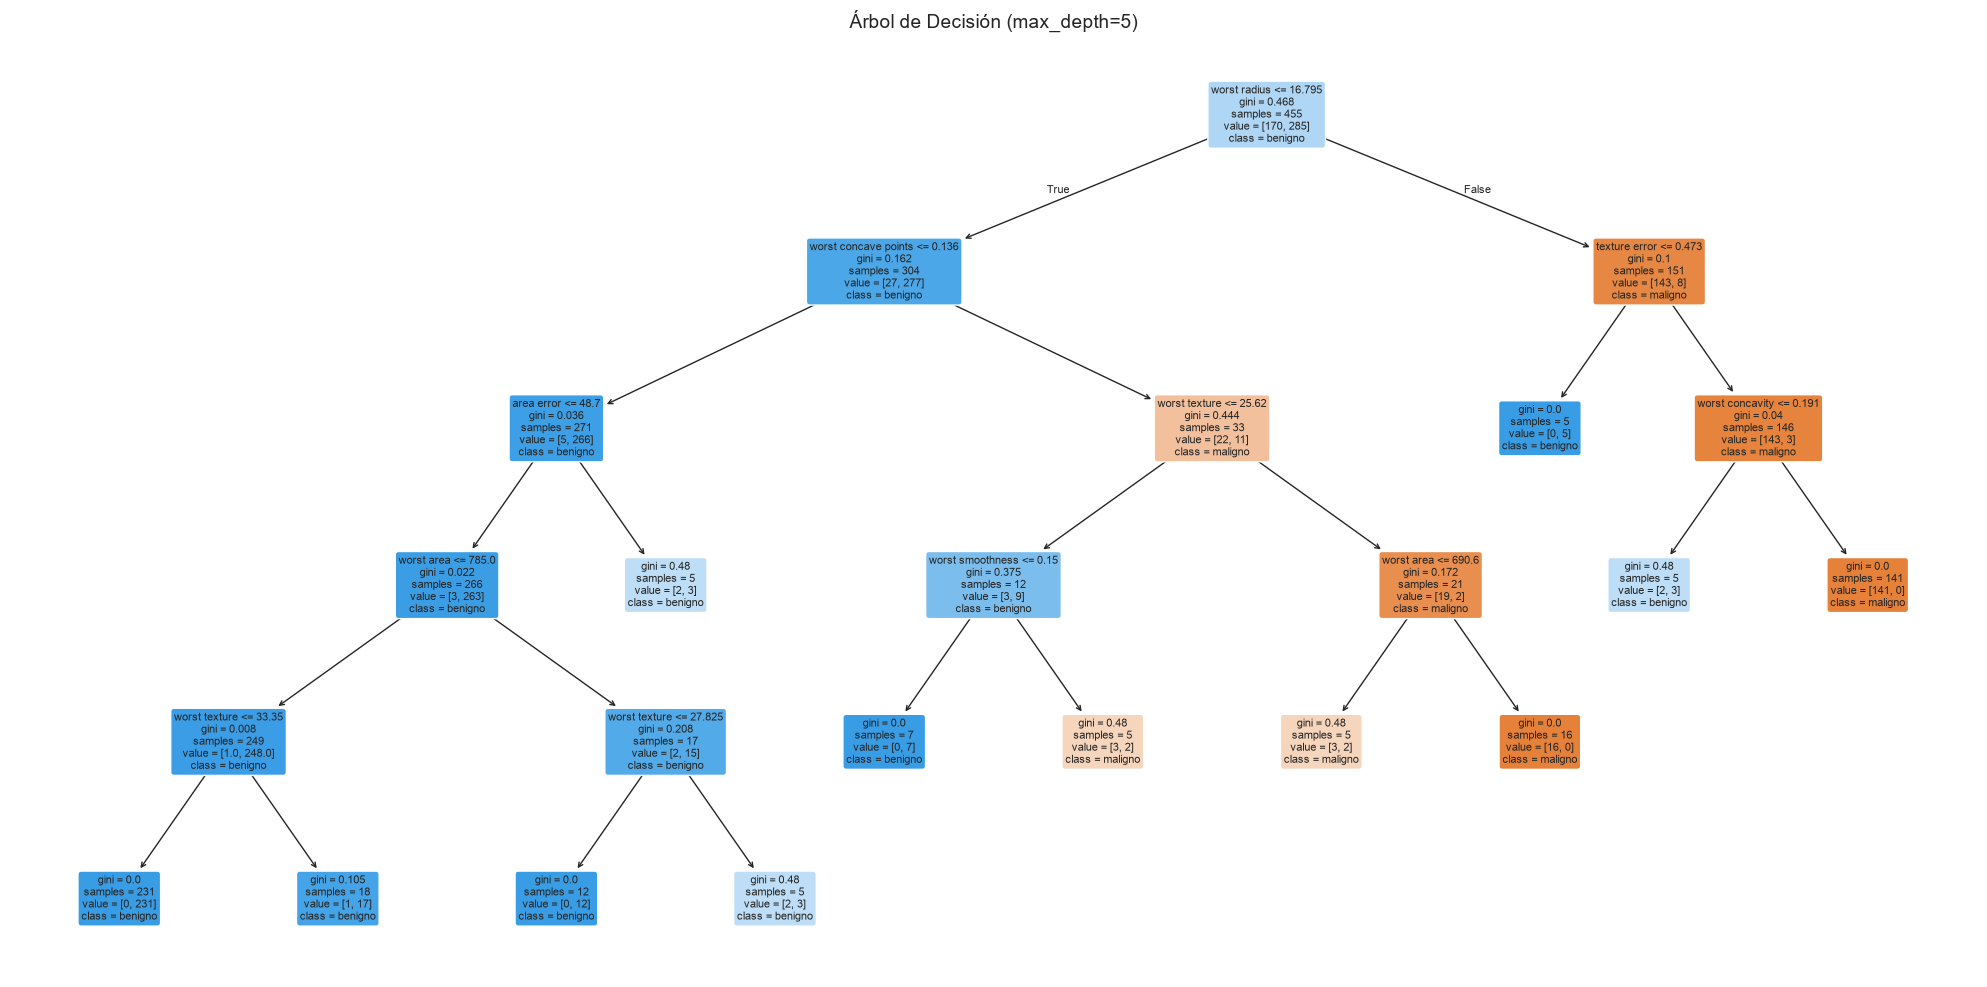

In [17]:
# 6.3  Visualización del árbol podado
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(pipe_dt.named_steps['clf'],
          feature_names=data.feature_names,
          class_names=['maligno', 'benigno'],
          filled=True, rounded=True, fontsize=8, ax=ax)
ax.set_title('Árbol de Decisión (max_depth=5)', fontsize=14)
plt.tight_layout()
plt.show()

=== Árbol de Decisión ===
  Accuracy: 0.9211
  Precision: 0.9437
  Recall: 0.9306
  F1-Score: 0.9371


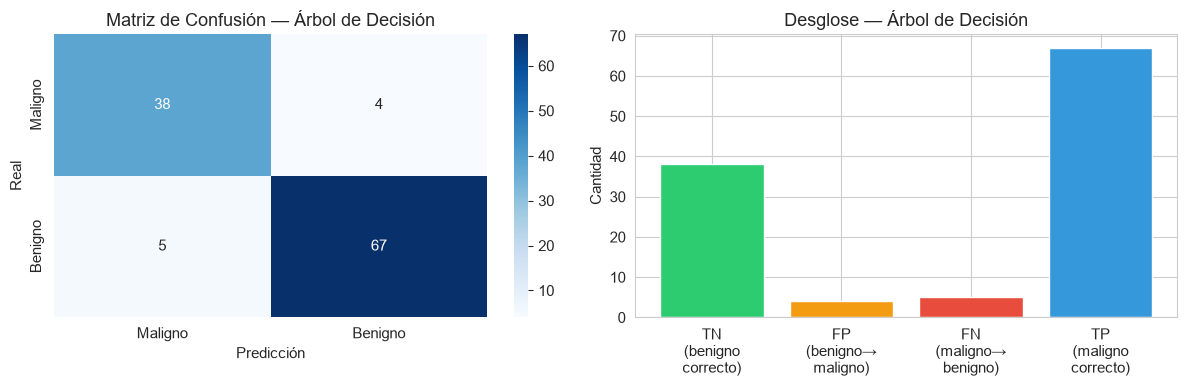


  FN (maligno no detectado): 5
  FP (benigno como maligno): 4

Reporte completo:
              precision    recall  f1-score   support

     maligno       0.88      0.90      0.89        42
     benigno       0.94      0.93      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114



In [18]:
# 6.4  Evaluación completa
metrics_dt = eval_classifier(pipe_dt, X_train, y_train, X_test, y_test,
                             'Árbol de Decisión')

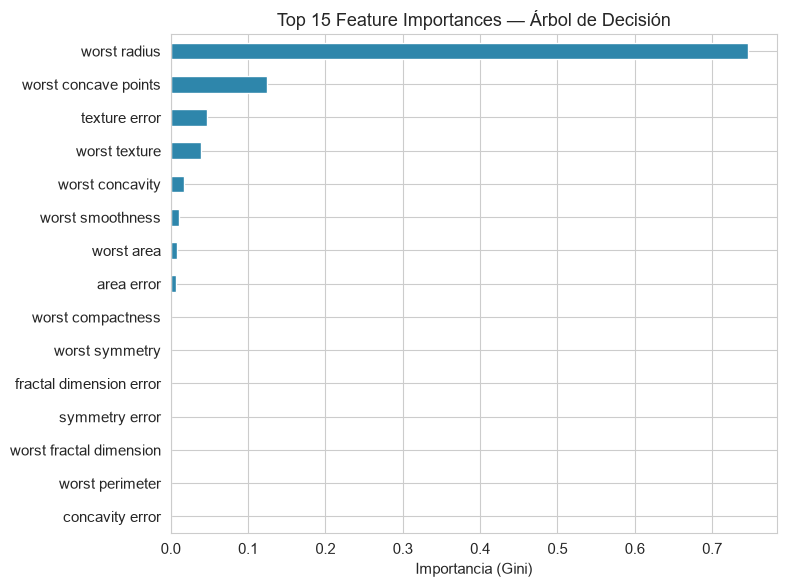

In [19]:
# 6.5  Importancia de features
importances = pd.Series(
    pipe_dt.named_steps['clf'].feature_importances_,
    index=data.feature_names
).sort_values(ascending=True)

# Top 15
top_imp = importances.tail(15)
fig, ax = plt.subplots(figsize=(8, 6))
top_imp.plot(kind='barh', ax=ax, color='#2E86AB')
ax.set_title('Top 15 Feature Importances — Árbol de Decisión')
ax.set_xlabel('Importancia (Gini)')
plt.tight_layout()
plt.show()

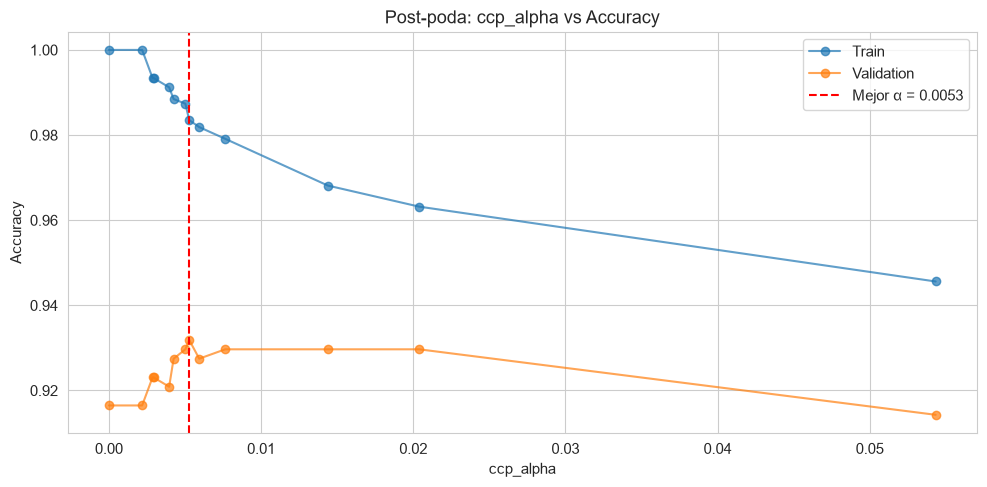

Mejor ccp_alpha: 0.005275


In [20]:
# 6.6  Post-poda con ccp_alpha
path = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(X_train, y_train)
alphas = path.ccp_alphas[:-1]  # excluir el último (árbol trivial)

train_scores, test_scores = [], []
for alpha in alphas:
    dt_temp = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    cv_temp = cross_validate(dt_temp, X_train, y_train, cv=skf,
                             scoring='accuracy', return_train_score=True)
    train_scores.append(cv_temp['train_score'].mean())
    test_scores.append(cv_temp['test_score'].mean())

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(alphas, train_scores, 'o-', label='Train', alpha=0.7)
ax.plot(alphas, test_scores, 'o-', label='Validation', alpha=0.7)
best_idx = np.argmax(test_scores)
ax.axvline(x=alphas[best_idx], color='red', linestyle='--',
           label=f'Mejor α = {alphas[best_idx]:.4f}')
ax.set_xlabel('ccp_alpha')
ax.set_ylabel('Accuracy')
ax.set_title('Post-poda: ccp_alpha vs Accuracy')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Mejor ccp_alpha: {alphas[best_idx]:.6f}')

---
## 7. Modelo 3 — Support Vector Machine (SVM)

**Fundamento:** SVM busca el hiperplano de máximo margen γ = 2/‖w‖ que separa las clases. Con margen suave, permite violaciones controladas: min ½‖w‖² + C·Σξᵢ. El kernel trick transforma el espacio para manejar no linealidad.

In [21]:
# 7.1  Pipeline SVM con kernel RBF
pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(kernel='rbf', C=1.0, probability=True, random_state=42))
])

cv_svm = cross_validate(pipe_svm, X_train, y_train, cv=skf,
                        scoring=['accuracy', 'f1', 'recall'],
                        return_train_score=True)

print('SVM (RBF, C=1.0) — CV 5-fold')
print(f'  Accuracy:  {cv_svm["test_accuracy"].mean():.4f} ± {cv_svm["test_accuracy"].std():.4f}')
print(f'  F1-Score:  {cv_svm["test_f1"].mean():.4f} ± {cv_svm["test_f1"].std():.4f}')
print(f'  Recall:    {cv_svm["test_recall"].mean():.4f} ± {cv_svm["test_recall"].std():.4f}')

pipe_svm.fit(X_train, y_train)
y_pred_svm = pipe_svm.predict(X_test)

SVM (RBF, C=1.0) — CV 5-fold
  Accuracy:  0.9692 ± 0.0146
  F1-Score:  0.9756 ± 0.0113
  Recall:    0.9789 ± 0.0131


=== SVM (RBF) ===
  Accuracy: 0.9825
  Precision: 0.9861
  Recall: 0.9861
  F1-Score: 0.9861


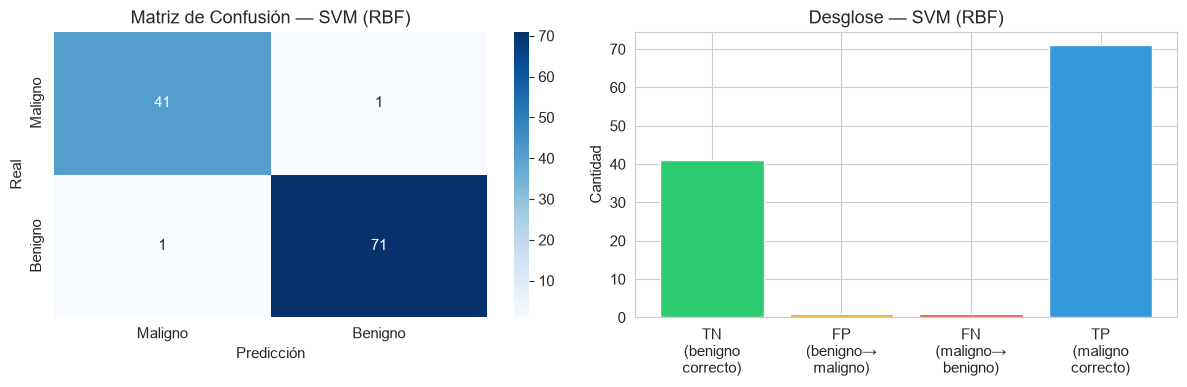


  FN (maligno no detectado): 1
  FP (benigno como maligno): 1

Reporte completo:
              precision    recall  f1-score   support

     maligno       0.98      0.98      0.98        42
     benigno       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [22]:
# 7.2  Evaluación completa
metrics_svm = eval_classifier(pipe_svm, X_train, y_train, X_test, y_test, 'SVM (RBF)')

  Kernel linear  : Accuracy = 0.9648
  Kernel rbf     : Accuracy = 0.9692
  Kernel poly    : Accuracy = 0.8967


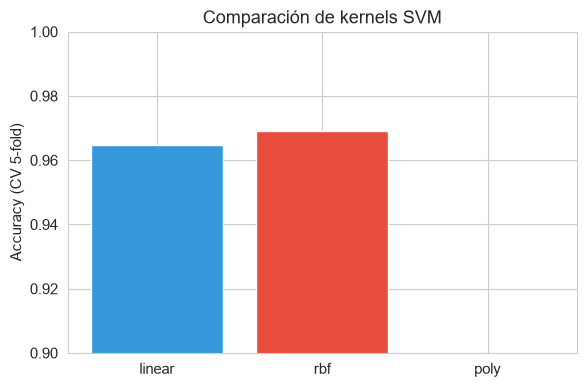

In [23]:
# 7.3  Comparación de kernels
kernels = ['linear', 'rbf', 'poly']
kernel_results = {}

for k in kernels:
    pipe_k = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel=k, C=1.0, probability=True, random_state=42))
    ])
    cv_k = cross_validate(pipe_k, X_train, y_train, cv=skf,
                          scoring='accuracy')
    kernel_results[k] = cv_k['test_score'].mean()
    print(f'  Kernel {k:8s}: Accuracy = {kernel_results[k]:.4f}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(kernel_results.keys(), kernel_results.values(), color=['#3498db', '#e74c3c', '#2ecc71'])
ax.set_ylabel('Accuracy (CV 5-fold)')
ax.set_title('Comparación de kernels SVM')
ax.set_ylim(0.9, 1.0)
plt.tight_layout()
plt.show()

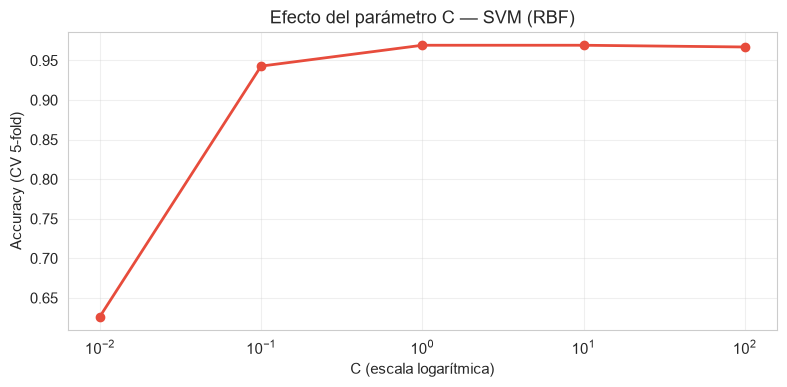


Interpretación:
  C bajo → margen amplio, más errores permitidos (mayor sesgo)
  C alto → margen estrecho, menos errores permitidos (mayor varianza)


In [24]:
# 7.4  Efecto del parámetro C
C_values = [0.01, 0.1, 1, 10, 100]
c_scores = []

for c in C_values:
    pipe_c = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', C=c, random_state=42))
    ])
    cv_c = cross_validate(pipe_c, X_train, y_train, cv=skf, scoring='accuracy')
    c_scores.append(cv_c['test_score'].mean())

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(C_values, c_scores, 'o-', color='#e74c3c', linewidth=2)
ax.set_xlabel('C (escala logarítmica)')
ax.set_ylabel('Accuracy (CV 5-fold)')
ax.set_title('Efecto del parámetro C — SVM (RBF)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\nInterpretación:')
print('  C bajo → margen amplio, más errores permitidos (mayor sesgo)')
print('  C alto → margen estrecho, menos errores permitidos (mayor varianza)')

---
## 8. Modelo 4 — K-Nearest Neighbors (KNN)

**Fundamento:** Algoritmo de aprendizaje basado en instancias (lazy learning). No construye un modelo explícito; clasifica por voto mayoritario de los K vecinos más cercanos según distancia Euclidiana (por defecto). La regla empírica sugiere K ≈ √n.

In [25]:
# 8.1  Pipeline KNN
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier(n_neighbors=5))
])

cv_knn = cross_validate(pipe_knn, X_train, y_train, cv=skf,
                        scoring=['accuracy', 'f1', 'recall'],
                        return_train_score=True)

print('KNN (K=5) — CV 5-fold')
print(f'  Accuracy:  {cv_knn["test_accuracy"].mean():.4f} ± {cv_knn["test_accuracy"].std():.4f}')
print(f'  F1-Score:  {cv_knn["test_f1"].mean():.4f} ± {cv_knn["test_f1"].std():.4f}')
print(f'  Recall:    {cv_knn["test_recall"].mean():.4f} ± {cv_knn["test_recall"].std():.4f}')

pipe_knn.fit(X_train, y_train)
y_pred_knn = pipe_knn.predict(X_test)

KNN (K=5) — CV 5-fold
  Accuracy:  0.9626 ± 0.0112
  F1-Score:  0.9705 ± 0.0091
  Recall:    0.9825 ± 0.0192


=== KNN (K=5) ===
  Accuracy: 0.9561
  Precision: 0.9589
  Recall: 0.9722
  F1-Score: 0.9655


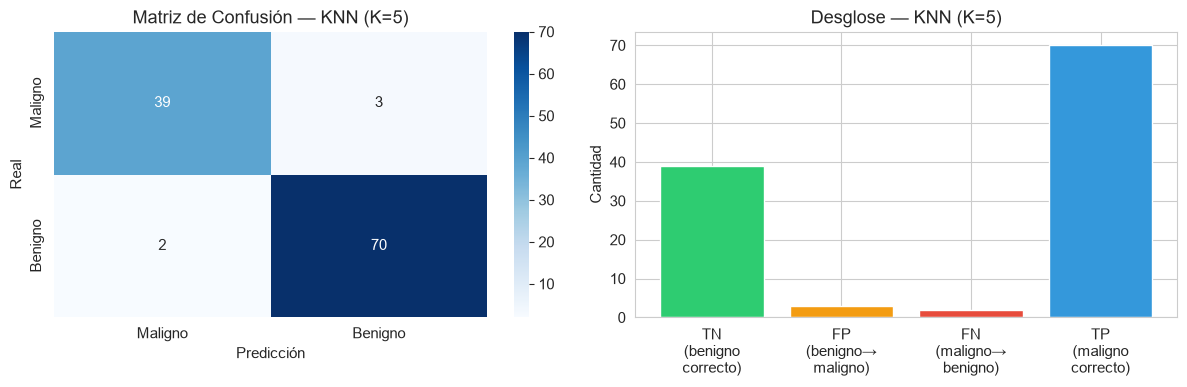


  FN (maligno no detectado): 2
  FP (benigno como maligno): 3

Reporte completo:
              precision    recall  f1-score   support

     maligno       0.95      0.93      0.94        42
     benigno       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [26]:
# 8.2  Evaluación completa
metrics_knn = eval_classifier(pipe_knn, X_train, y_train, X_test, y_test, 'KNN (K=5)')

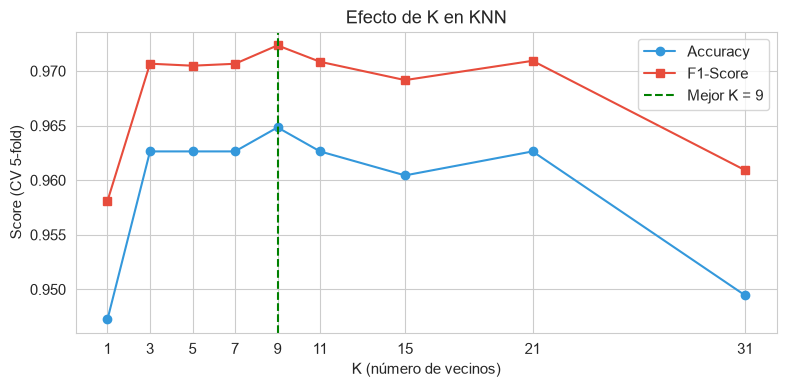

Mejor K por F1: 9
K empírico (√455): 21


In [27]:
# 8.3  Búsqueda del K óptimo
k_values = [1, 3, 5, 7, 9, 11, 15, 21, 31]
k_scores_acc = []
k_scores_f1 = []

for k in k_values:
    pipe_k = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=k))
    ])
    cv_k = cross_validate(pipe_k, X_train, y_train, cv=skf,
                          scoring=['accuracy', 'f1'])
    k_scores_acc.append(cv_k['test_accuracy'].mean())
    k_scores_f1.append(cv_k['test_f1'].mean())

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_values, k_scores_acc, 'o-', label='Accuracy', color='#3498db')
ax.plot(k_values, k_scores_f1, 's-', label='F1-Score', color='#e74c3c')
best_k = k_values[np.argmax(k_scores_f1)]
ax.axvline(x=best_k, color='green', linestyle='--', label=f'Mejor K = {best_k}')
ax.set_xlabel('K (número de vecinos)')
ax.set_ylabel('Score (CV 5-fold)')
ax.set_title('Efecto de K en KNN')
ax.legend()
ax.set_xticks(k_values)
plt.tight_layout()
plt.show()

print(f'Mejor K por F1: {best_k}')
print(f'K empírico (√{len(X_train)}): {int(np.sqrt(len(X_train)))}')

In [28]:
# 8.4  Comparación de métricas de distancia
distances = ['euclidean', 'manhattan', 'minkowski']
dist_results = {}

for d in distances:
    p_val = 3 if d == 'minkowski' else 2
    pipe_d = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=5, metric=d, p=p_val))
    ])
    cv_d = cross_validate(pipe_d, X_train, y_train, cv=skf, scoring='f1')
    dist_results[d] = cv_d['test_score'].mean()
    label = f'{d} (p={p_val})' if d == 'minkowski' else d
    print(f'  Distancia {label:20s}: F1 = {dist_results[d]:.4f}')

  Distancia euclidean           : F1 = 0.9705
  Distancia manhattan           : F1 = 0.9705
  Distancia minkowski (p=3)     : F1 = 0.9658


---
## 9. Comparación final de modelos

In [29]:
# 9.1  Tabla resumen de métricas
all_models = {
    'Regresión Logística': pipe_lr,
    'Árbol de Decisión': pipe_dt,
    'SVM (RBF)': pipe_svm,
    'KNN (K=5)': pipe_knn
}

all_metrics = {}
for name, model in all_models.items():
    y_pred = model.predict(X_test)
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc_val = auc(fpr, tpr)
    elif hasattr(model, 'decision_function'):
        y_score = model.decision_function(X_test)
        fpr, tpr, _ = roc_curve(y_test, y_score)
        roc_auc_val = auc(fpr, tpr)
    else:
        roc_auc_val = None
    
    all_metrics[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC': roc_auc_val
    }

metrics_df = pd.DataFrame(all_metrics).T.round(4)
print('=== Tabla comparativa de métricas (Test Set) ===')
metrics_df

=== Tabla comparativa de métricas (Test Set) ===


,Accuracy,Precision,Recall,F1-Score,AUC
Regresión Logística,0.9825,0.9861,0.9861,0.9861,0.9954
Árbol de Decisión,0.9211,0.9437,0.9306,0.9371,0.9368
SVM (RBF),0.9825,0.9861,0.9861,0.9861,0.9950
KNN (K=5),0.9561,0.9589,0.9722,0.9655,0.9788


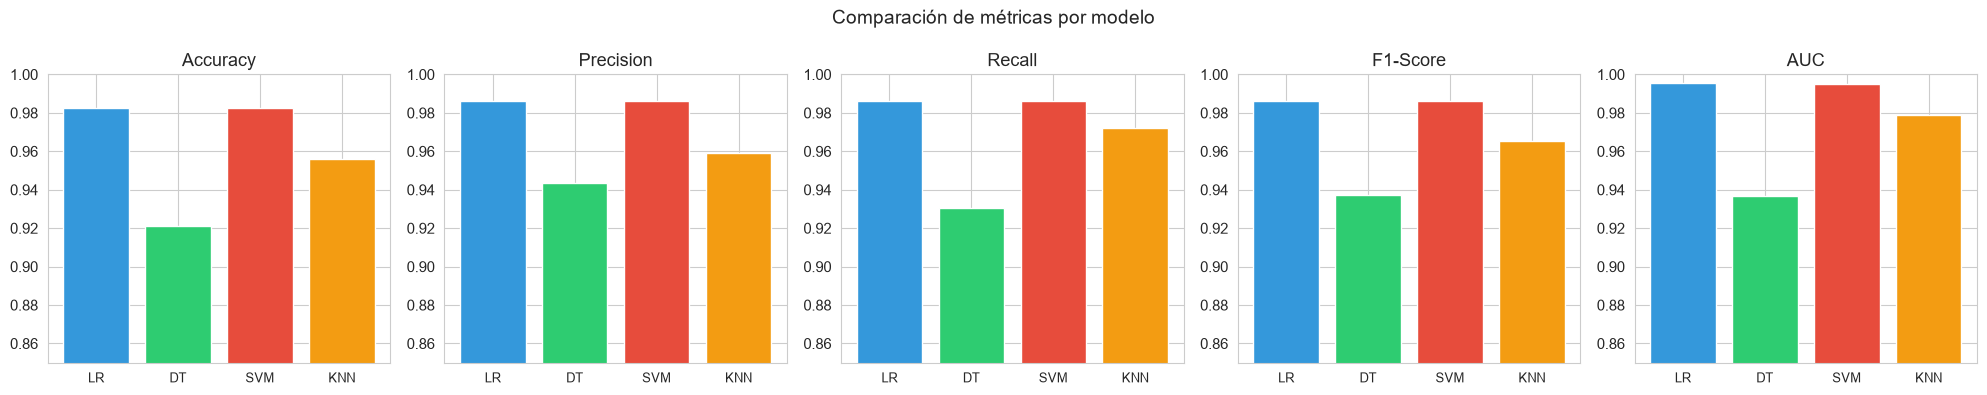

In [30]:
# 9.2  Gráfico de barras comparativo
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
colors_models = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for i, metric in enumerate(metric_names):
    values = [all_metrics[m][metric] for m in all_metrics]
    axes[i].bar(range(len(values)), values, color=colors_models)
    axes[i].set_title(metric)
    axes[i].set_ylim(0.85, 1.0)
    axes[i].set_xticks(range(len(values)))
    axes[i].set_xticklabels(['LR', 'DT', 'SVM', 'KNN'], fontsize=9)

plt.suptitle('Comparación de métricas por modelo', fontsize=14)
plt.tight_layout()
plt.show()

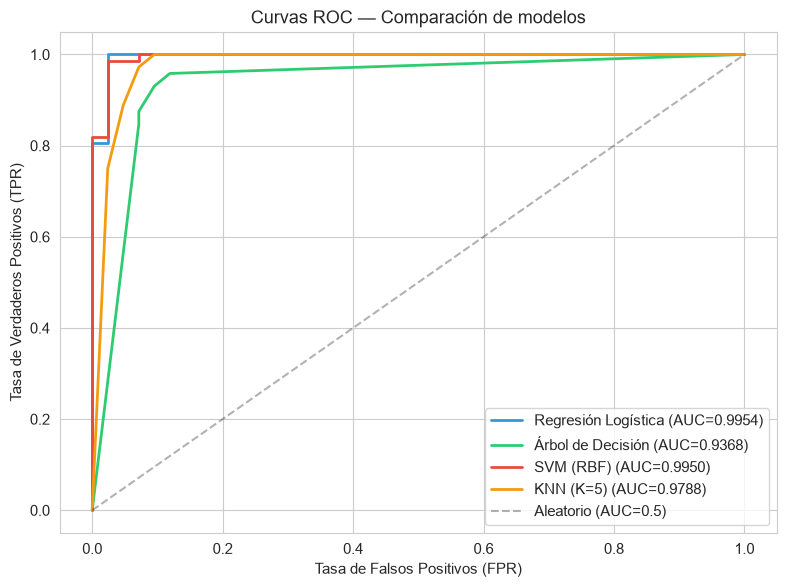

In [31]:
# 9.3  Curvas ROC superpuestas
fig, ax = plt.subplots(figsize=(8, 6))

for (name, model), color in zip(all_models.items(), colors_models):
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_prob = model.decision_function(X_test)
    else:
        continue
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=2, color=color,
            label=f'{name} (AUC={roc_auc_val:.4f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Aleatorio (AUC=0.5)')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
ax.set_title('Curvas ROC — Comparación de modelos')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [32]:
# 9.4  Matriz de selección
selection_matrix = pd.DataFrame({
    'Modelo': ['Reg. Logística', 'Árbol de Decisión', 'SVM (RBF)', 'KNN'],
    'Precisión predictiva': ['★★★★☆', '★★★☆☆', '★★★★★', '★★★★☆'],
    'Velocidad (train+pred)': ['★★★★★', '★★★★☆', '★★★☆☆', '★★★★★'],
    'Interpretabilidad': ['★★★★☆', '★★★★★', '★★☆☆☆', '★★★☆☆'],
    'Escalabilidad': ['★★★★★', '★★★★☆', '★★☆☆☆', '★★☆☆☆'],
    'Robustez a outliers': ['★★★☆☆', '★★★★☆', '★★★★☆', '★★☆☆☆']
}).set_index('Modelo')

print('=== Matriz de Selección de Modelos ===')
selection_matrix

=== Matriz de Selección de Modelos ===


,Precisión predictiva,Velocidad (train+pred),Interpretabilidad,Escalabilidad,Robustez a outliers
Modelo,,,,,
Reg. Logística,★★★★☆,★★★★★,★★★★☆,★★★★★,★★★☆☆
Árbol de Decisión,★★★☆☆,★★★★☆,★★★★★,★★★★☆,★★★★☆
SVM (RBF),★★★★★,★★★☆☆,★★☆☆☆,★★☆☆☆,★★★★☆
KNN,★★★★☆,★★★★★,★★★☆☆,★★☆☆☆,★★☆☆☆


---
## 10. Resumen comparativo

| Modelo | Fortalezas | Limitaciones | ¿Cuándo usarlo? |
|---|---|---|---|
| **Reg. Logística** | Interpretable, probabilístico, rápido | Asume linealidad en log-odds | Clasificación binaria con necesidad de interpretabilidad |
| **Árbol de Decisión** | Explicable, maneja tipos mixtos | Propenso a sobreajuste sin poda | Reglas de negocio, explicabilidad ante stakeholders |
| **SVM** | Efectivo en alta dimensión, robusto al ruido | Lento con muchos datos, difícil de interpretar | Datasets de dimensión media-alta, márgenes claros |
| **KNN** | Simple, no paramétrico, flexible | Lento en predicción, maldición de la dimensionalidad | Datasets pequeños-medianos con features normalizadas |

**Criterio de selección final:** En este dataset médico, **Recall** es la métrica prioritaria (minimizar falsos negativos). El modelo con mejor Recall en test es el candidato preferido para despliegue.

---
## 11. Ejercicios propuestos

### Ejercicio 1 — Optimización con GridSearchCV
Para cada modelo, realice una búsqueda exhaustiva de hiperparámetros con `GridSearchCV(cv=5, scoring='f1')`. Parámetros sugeridos:
- **LogisticRegression:** C=[0.01, 0.1, 1, 10, 100]
- **DecisionTree:** max_depth=[3,5,7,10,None], min_samples_leaf=[1,5,10]
- **SVM:** C=[0.1,1,10], gamma=[0.001,0.01,0.1]
- **KNN:** n_neighbors=[3,5,9,15,21], weights=['uniform','distance']

Compare los mejores modelos optimizados.

### Ejercicio 2 — Manejo de desbalance con class_weight y SMOTE
Entrene los 4 modelos con `class_weight='balanced'`. Compare Recall de la clase maligna con y sin balanceo. Además, aplique SMOTE:
```python
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)
```

### Ejercicio 3 — Dataset propio
Seleccione un dataset de clasificación de Kaggle/UCI (mín. 500 registros, 5 features). Aplique los 4 modelos + al menos 1 adicional (Random Forest, Gradient Boosting o Naive Bayes). Documente métricas, curvas ROC, matriz de selección y justificación del mejor modelo.

### Ejercicio 1 — Optimización con GridSearchCV

**Objetivo.** Buscar los mejores hiperparámetros de los cuatro modelos y comprobar si la optimización mejora su rendimiento en el conjunto de test.

**Método.**
- Cada modelo se define como un `Pipeline`, de modo que el escalado se ajusta solo con los datos de entrenamiento de cada fold (sin fuga de información).
- Se usa `GridSearchCV` con la misma validación cruzada estratificada de 5 folds (`skf`) y `scoring='f1'`.
- El test (114 muestras: 42 malignas y 72 benignas) se usa una sola vez, al final.

| Modelo | Hiperparámetros explorados |
|---|---|
| Regresión Logística | `C`: 0.01, 0.1, 1, 10, 100 |
| Árbol de Decisión | `max_depth`: 3, 5, 7, 10, None; `min_samples_leaf`: 1, 5, 10 |
| SVM (RBF) | `C`: 0.1, 1, 10; `gamma`: 0.001, 0.01, 0.1 |
| KNN | `n_neighbors`: 3, 5, 9, 15, 21; `weights`: uniform, distance |

**Aclaración sobre la métrica.** En este dataset la clase positiva es benigno (1), así que `scoring='f1'` optimiza el F1 de la clase benigna. Para evaluar la detección de tumores malignos, la tabla de test reporta además el recall de la clase maligna (`pos_label=0`) y el conteo de malignos no detectados (`cm[0, 1]`).

In [33]:
# 10.1  Búsqueda de hiperparámetros con GridSearchCV

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score

configs_gs = {
    'Regresión Logística': (
        Pipeline([('scaler', StandardScaler()),
                  ('clf', LogisticRegression(max_iter=1000, random_state=42))]),
        {'clf__C': [0.01, 0.1, 1, 10, 100]}),
    'Árbol de Decisión': (
        Pipeline([('clf', DecisionTreeClassifier(random_state=42))]),
        {'clf__max_depth': [3, 5, 7, 10, None],
         'clf__min_samples_leaf': [1, 5, 10]}),
    'SVM (RBF)': (
        Pipeline([('scaler', StandardScaler()),
                  ('clf', SVC(kernel='rbf', probability=True, random_state=42))]),
        {'clf__C': [0.1, 1, 10], 'clf__gamma': [0.001, 0.01, 0.1]}),
    'KNN': (
        Pipeline([('scaler', StandardScaler()),
                  ('clf', KNeighborsClassifier())]),
        {'clf__n_neighbors': [3, 5, 9, 15, 21],
         'clf__weights': ['uniform', 'distance']}),
}

best_gs = {}
for name, (pipe, grid) in configs_gs.items():
    gs = GridSearchCV(pipe, grid, cv=skf, scoring='f1', n_jobs=-1)
    gs.fit(X_train, y_train)
    best_gs[name] = gs
    print(f'{name}: {gs.best_params_}  F1 CV = {gs.best_score_:.4f}')

Regresión Logística: {'clf__C': 0.1}  F1 CV = 0.9861
Árbol de Decisión: {'clf__max_depth': 3, 'clf__min_samples_leaf': 5}  F1 CV = 0.9460
SVM (RBF): {'clf__C': 10, 'clf__gamma': 0.01}  F1 CV = 0.9810
KNN: {'clf__n_neighbors': 9, 'clf__weights': 'uniform'}  F1 CV = 0.9724


In [34]:
# 10.2  Tabla resumen de métricas con mejores hiperparámetros

filas = []
for name, gs in best_gs.items():
    y_pred = gs.predict(X_test)
    y_prob = gs.predict_proba(X_test)[:, 1]
    cm = confusion_matrix(y_test, y_pred)   # filas: real [maligno, benigno]
    filas.append({
        'Modelo': name,
        'F1 CV (grid)': gs.best_score_,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall (benigno)': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_prob),
        'Recall maligno': recall_score(y_test, y_pred, pos_label=0),
        'Maligno no detectado': cm[0, 1],
        'Benigno como maligno': cm[1, 0],
    })
tabla_gs = pd.DataFrame(filas).set_index('Modelo').round(4)
tabla_gs.T

Modelo,Regresión Logística,Árbol de Decisión,SVM (RBF),KNN
F1 CV (grid),0.9861,0.9460,0.9810,0.9724
Accuracy,0.9737,0.9386,0.9825,0.9737
Precision,0.9726,0.9452,0.9861,0.9600
Recall (benigno),0.9861,0.9583,0.9861,1.0000
F1,0.9793,0.9517,0.9861,0.9796
AUC,0.9957,0.9439,0.9977,0.9944
Recall maligno,0.9524,0.9048,0.9762,0.9286
Maligno no detectado,2.0000,4.0000,1.0000,3.0000
Benigno como maligno,1.0000,3.0000,1.0000,0.0000


#### Resultados y conclusiones — Ejercicio 1

| | Reg. Logística | Árbol | SVM (RBF) | KNN |
|---|---|---|---|---|
| Mejores parámetros | C=0.1 | depth=3, leaf=5 | C=10, γ=0.01 | k=9, uniform |
| F1 CV (grid) | 0.9861 | 0.9460 | 0.9810 | 0.9724 |
| Accuracy test | 0.9737 | 0.9386 | 0.9825 | 0.9737 |
| F1 test (benigno) | 0.9793 | 0.9517 | 0.9861 | 0.9796 |
| AUC test | 0.9957 | 0.9439 | 0.9977 | 0.9944 |
| Recall maligno | 0.9524 | 0.9048 | 0.9762 | 0.9286 |
| Malignos no detectados | 2 | 4 | 1 | 3 |

1. **El SVM optimizado obtiene el mejor resultado en test** en F1, AUC, accuracy y recall de la clase maligna (deja pasar 1 tumor maligno de 42).
2. **La optimización no mejora todos los modelos en test.** Frente a los modelos base, el árbol (F1 0.9371 → 0.9517) y KNN (0.9655 → 0.9796) mejoran. El SVM mantiene su F1 (0.9861) y sube el AUC de 0.9950 a 0.9977. La regresión logística pasa de 1 a 2 malignos no detectados.
3. **Las diferencias entre regresión logística, SVM y KNN no son concluyentes.** Con solo 42 casos malignos, un error de diferencia equivale a 2.4 puntos de recall.
4. **El árbol de decisión queda claramente por debajo** en todas las métricas.

### Ejercicio 2 — Manejo de desbalance con `class_weight` y SMOTE

**Objetivo.** Evaluar si compensar el desbalance de clases mejora la detección de tumores malignos, comparando tres variantes por modelo: sin balanceo, `class_weight='balanced'` y SMOTE.

**Desbalance en los datos.** En train hay 285 benignos y 170 malignos (63 % / 37 %). Es un desbalance leve. Tras aplicar SMOTE sobre el train, las clases quedan en 285 / 285.

**Método.**
- Se mantienen los hiperparámetros base del notebook, para que la única diferencia entre variantes sea el balanceo.
- SMOTE se incluye dentro de un `Pipeline` de `imblearn`, después del escalado y solo sobre los datos de entrenamiento de cada fold. Aplicarlo antes de la validación cruzada filtraría muestras sintéticas a los folds de validación.
- KNN no admite `class_weight`, por lo que solo se compara sin balanceo y con SMOTE.
- La métrica principal es el **recall de la clase maligna** (`pos_label=0`), porque no detectar un tumor maligno es el error más costoso. También se reporta la precisión de esa clase, para ver el costo en falsas alarmas.
- Se añade el recall en validación cruzada, porque el test tiene solo 42 casos malignos y una diferencia de un caso mueve el recall 2.4 puntos.

In [36]:
# 11.1  Comparación de estrategias de balanceo

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer

def crear_clf(nombre, cw=None):
    if nombre == 'Regresión Logística':
        return LogisticRegression(max_iter=1000, random_state=42, class_weight=cw)
    if nombre == 'Árbol de Decisión':
        return DecisionTreeClassifier(max_depth=5, min_samples_split=10,
                                      min_samples_leaf=5, random_state=42, class_weight=cw)
    if nombre == 'SVM (RBF)':
        return SVC(kernel='rbf', C=1.0, random_state=42, class_weight=cw)
    return KNeighborsClassifier(n_neighbors=5)          # KNN: sin class_weight

nombres = ['Regresión Logística', 'Árbol de Decisión', 'SVM (RBF)', 'KNN (K=5)']
usa_escala = {'Regresión Logística': True, 'Árbol de Decisión': False,
              'SVM (RBF)': True, 'KNN (K=5)': True}

def construir(nombre, variante):
    pasos = [('scaler', StandardScaler())] if usa_escala[nombre] else []
    if variante == 'SMOTE':
        pasos += [('smote', SMOTE(random_state=42)), ('clf', crear_clf(nombre))]
        return ImbPipeline(pasos)
    cw = 'balanced' if variante == 'balanced' else None
    return Pipeline(pasos + [('clf', crear_clf(nombre, cw))])

rec_maligno = make_scorer(recall_score, pos_label=0)
filas = []
for n in nombres:
    for v in ['sin balanceo', 'balanced', 'SMOTE']:
        if v == 'balanced' and n == 'KNN (K=5)':
            continue
        p = construir(n, v).fit(X_train, y_train)
        yp = p.predict(X_test)
        cm = confusion_matrix(y_test, yp)               # filas: real [maligno, benigno]
        cv = cross_val_score(construir(n, v), X_train, y_train, cv=skf, scoring=rec_maligno)
        filas.append({'Modelo': n, 'Variante': v,
                      'Recall maligno (test)': recall_score(y_test, yp, pos_label=0),
                      'Maligno no detectado': cm[0, 1],
                      'Benigno→maligno': cm[1, 0],
                      'Precision maligno': precision_score(y_test, yp, pos_label=0),
                      'Recall maligno (CV)': cv.mean(), 'CV std': cv.std()})
tabla_bal = pd.DataFrame(filas).set_index(['Modelo', 'Variante']).round(4)
tabla_bal

Recall maligno (test)  Maligno no detectado  \
Modelo              Variante                                                    
Regresión Logística sin balanceo                 0.9762                     1   
                    balanced                     0.9762                     1   
                    SMOTE                        0.9762                     1   
Árbol de Decisión   sin balanceo                 0.9048                     4   
                    balanced                     0.9048                     4   
                    SMOTE                        0.9286                     3   
SVM (RBF)           sin balanceo                 0.9762                     1   
                    balanced                     0.9762                     1   
                    SMOTE                        0.9762                     1   
KNN (K=5)           sin balanceo                 0.9286                     3   
                    SMOTE                        0.9286                     3   

                                  Benigno→maligno  Precision maligno  \
Modelo              Variante                                           
Regresión Logística sin balanceo                1             0.9762   
                    balanced                    4             0.9111   
                    SMOTE                       3             0.9318   
Árbol de Decisión   sin balanceo                5             0.8837   
                    balanced                    6             0.8636   
                    SMOTE                       4             0.9070   
SVM (RBF)           sin balanceo                1             0.9762   
                    balanced                    3             0.9318   
                    SMOTE                       2             0.9535   
KNN (K=5)           sin balanceo                2             0.9512   
                    SMOTE                       6             0.8667   

                                  Recall maligno (CV)  CV std  
Modelo              Variante                                   
Regresión Logística sin balanceo               0.9647  0.0288  
                    balanced                   0.9765  0.0118  
                    SMOTE                      0.9706  0.0186  
Árbol de Decisión   sin balanceo               0.9118  0.0416  
                    balanced                   0.9118  0.0322  
                    SMOTE                      0.9118  0.0558  
SVM (RBF)           sin balanceo               0.9529  0.0399  
                    balanced                   0.9706  0.0186  
                    SMOTE                      0.9647  0.0220  
KNN (K=5)           sin balanceo               0.9294  0.0235  
                    SMOTE                      0.9412  0.0263

#### Resultados y conclusiones — Ejercicio 2

| Modelo | Variante | Recall maligno test | Malignos no detectados | Benigno→maligno | Recall maligno CV |
|---|---|---|---|---|---|
| Reg. Logística | sin balanceo | 0.9762 | 1 | 1 | 0.9647 ± 0.029 |
| | balanced | 0.9762 | 1 | 4 | 0.9765 ± 0.012 |
| | SMOTE | 0.9762 | 1 | 3 | 0.9706 ± 0.019 |
| Árbol | sin balanceo | 0.9048 | 4 | 5 | 0.9118 ± 0.042 |
| | balanced | 0.9048 | 4 | 6 | 0.9118 ± 0.032 |
| | SMOTE | 0.9286 | 3 | 4 | 0.9118 ± 0.056 |
| SVM (RBF) | sin balanceo | 0.9762 | 1 | 1 | 0.9529 ± 0.040 |
| | balanced | 0.9762 | 1 | 3 | 0.9706 ± 0.019 |
| | SMOTE | 0.9762 | 1 | 2 | 0.9647 ± 0.022 |
| KNN (K=5) | sin balanceo | 0.9286 | 3 | 2 | 0.9294 ± 0.024 |
| | SMOTE | 0.9286 | 3 | 6 | 0.9412 ± 0.026 |

1. **En test, el balanceo casi no cambia el recall de la clase maligna.** Solo el árbol con SMOTE mejora (de 4 a 3 malignos no detectados).
2. **El costo aparece en las falsas alarmas.** La regresión logística pasa de 1 a 3-4 benignos clasificados como malignos, y KNN con SMOTE de 2 a 6.
3. **En validación cruzada, `balanced` mejora ligeramente el recall** de la regresión logística (0.9647 → 0.9765) y del SVM (0.9529 → 0.9706). La mejora es del mismo orden que la desviación estándar (0.02-0.04), por lo que no es una ganancia demostrada.
4. **Conclusión.** Con un desbalance de 37 % / 63 %, el balanceo no aporta una mejora clara y sí aumenta las falsas alarmas. Sería más relevante con un desbalance fuerte. Para reducir los malignos no detectados aquí, una alternativa más directa es ajustar el umbral de decisión.

---
*Ingeniería del Conocimiento (ISO56B) — UNCP — 2026-II*